# 🏥 Notebook 01 — EDA: Maternal Health Risk Dataset

**Tech Challenge Fase 4 | PosTech FIAP — IA para Devs**

---

## Objetivo

Este notebook realiza a **Análise Exploratória de Dados (EDA)** do dataset de risco em saúde materna.  
O dataset contém registros clínicos de gestantes com variáveis vitais e um rótulo de risco (`RiskLevel`).

### O que faremos:
1. Carregar e inspecionar os dados brutos
2. Análise estatística descritiva
3. Visualização das distribuições por nível de risco
4. Análise de correlações entre variáveis clínicas
5. Detecção de outliers
6. Conclusões e próximos passos para o pipeline de IA

---

**Dataset:** Maternal Health Risk Data Set (Kaggle)  
**Referência:** Ahmed, M. et al. (2020) — IoT-based risk assessment for maternal health  
**Variáveis:** Age, SystolicBP, DiastolicBP, BS (Blood Sugar), BodyTemp, HeartRate, RiskLevel

## 1. Importações e Configuração

Seguindo o padrão das aulas, importamos as bibliotecas principais de análise de dados.  
Usamos `pandas` para manipulação, `matplotlib` e `seaborn` para visualizações.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuração visual
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

print('Bibliotecas carregadas com sucesso!')
print(f'Pandas  : {pd.__version__}')
print(f'NumPy   : {np.__version__}')
print(f'Seaborn : {sns.__version__}')

Bibliotecas carregadas com sucesso!
Pandas  : 3.0.1
NumPy   : 2.4.3
Seaborn : 0.13.2


## 2. Carregamento dos Dados

Carregamos o CSV do dataset e fazemos uma inspeção inicial para entender sua estrutura:  
dimensões, tipos de dados, primeiras e últimas linhas.

In [2]:
DATA_PATH = Path('../data/datasets/maternal_risk/maternal_health_risk.csv')

df = pd.read_csv(DATA_PATH)

print(f'Shape do dataset: {df.shape}')
print(f'Colunas        : {list(df.columns)}')
print(f'\nPrimeiras linhas:')
df.head()

Shape do dataset: (1014, 7)
Colunas        : ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'RiskLevel']

Primeiras linhas:


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


### 2.1 Tipos de Dados e Valores Ausentes

Verificamos os tipos de cada coluna e se há valores nulos — um passo fundamental antes de qualquer análise.

In [3]:
print('=== Tipos de dados ===')
print(df.dtypes)

print('\n=== Valores ausentes por coluna ===')
nulos = df.isnull().sum()
print(nulos)

if nulos.sum() == 0:
    print('\n✅ Dataset completo: nenhum valor ausente!')
else:
    print(f'\n⚠️ Total de valores ausentes: {nulos.sum()}')

=== Tipos de dados ===
Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel          str
dtype: object

=== Valores ausentes por coluna ===
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

✅ Dataset completo: nenhum valor ausente!


### 2.2 Padronização do Rótulo

A coluna `RiskLevel` é nossa variável-alvo.  
Verificamos os valores únicos e criamos uma versão numérica ordenada para análises.

In [4]:
print('Valores únicos em RiskLevel:')
print(df['RiskLevel'].value_counts())

# Mapeamento ordinal: low < mid < high
risk_map = {'low risk': 0, 'mid risk': 1, 'high risk': 2}
df['RiskLevel_num'] = df['RiskLevel'].map(risk_map)

print('\nMapeamento aplicado:')
print(risk_map)

Valores únicos em RiskLevel:
RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

Mapeamento aplicado:
{'low risk': 0, 'mid risk': 1, 'high risk': 2}


## 3. Análise Estatística Descritiva

O `describe()` nos dá uma visão geral das distribuições: média, desvio padrão, mínimo, máximo e quartis.  
Isso nos ajuda a identificar valores suspeitos (ex: pressão arterial de 0 ou temperatura impossível).

In [5]:
df.describe().round(2)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel_num
count,1014.00,1014.0,1014.00,1014.00,1014.00,1014.00,1014.00
mean,29.87,113.2,76.46,8.73,98.67,74.30,0.87
std,13.47,18.4,13.89,3.29,1.37,8.09,0.81
min,10.00,70.0,49.00,6.00,98.00,7.00,0.00
25%,19.00,100.0,65.00,6.90,98.00,70.00,0.00
50%,26.00,120.0,80.00,7.50,98.00,76.00,1.00
75%,39.00,120.0,90.00,8.00,98.00,80.00,2.00
max,70.00,160.0,100.00,19.00,103.00,90.00,2.00


### 3.1 Estatísticas por Nível de Risco

Agrupamos os dados por `RiskLevel` para entender como cada variável clínica se comporta  
em cada categoria de risco — essa é a análise central para o nosso modelo preditivo.

In [6]:
features = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

stats_by_risk = df.groupby('RiskLevel')[features].mean().round(2)

# Reordenar: low -> mid -> high
stats_by_risk = stats_by_risk.reindex(['low risk', 'mid risk', 'high risk'])

print('=== Médias por Nível de Risco ===')
stats_by_risk

=== Médias por Nível de Risco ===


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
RiskLevel,,,,,,
low risk,26.87,105.87,72.53,7.22,98.37,72.77
mid risk,28.36,113.15,74.23,7.80,98.83,74.18
high risk,36.22,124.19,85.07,12.12,98.90,76.74


## 4. Distribuição dos Rótulos (Classes)

Verificamos se o dataset está balanceado entre as classes.  
Um desbalanceamento severo exige estratégias como oversampling (SMOTE) ou pesos de classe no modelo.

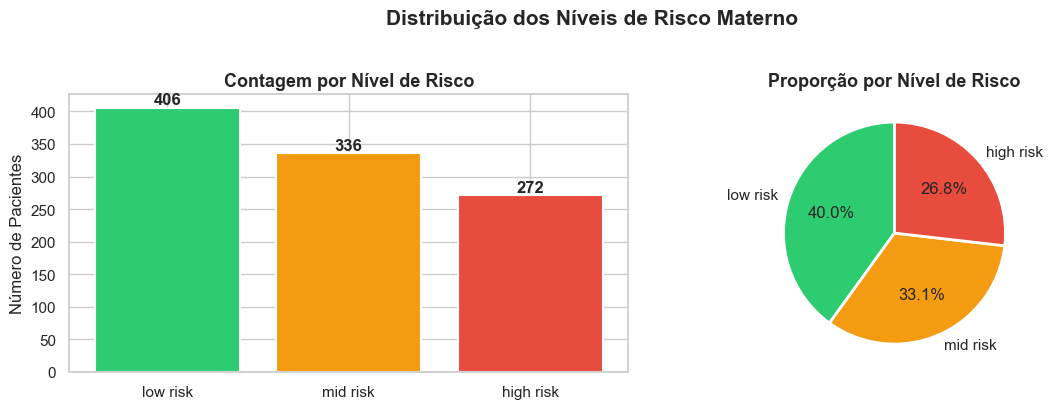

Distribuição absoluta:
RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Contagem absoluta
order = ['low risk', 'mid risk', 'high risk']
colors = ['#2ecc71', '#f39c12', '#e74c3c']
counts = df['RiskLevel'].value_counts().reindex(order)

axes[0].bar(order, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Contagem por Nível de Risco', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de Pacientes')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Proporção
axes[1].pie(
    counts.values,
    labels=order,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporção por Nível de Risco', fontsize=13, fontweight='bold')

plt.suptitle('Distribuição dos Níveis de Risco Materno', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Distribuição absoluta:')
print(counts)

## 5. Distribuição das Variáveis Clínicas por Risco

Boxplots permitem visualizar rapidamente a dispersão e a separação entre os grupos.  
Variáveis com boa separação entre classes são as mais informativas para o modelo.

C:\Users\T-GAMER\AppData\Local\Temp\ipykernel_33232\1612583119.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\T-GAMER\AppData\Local\Temp\ipykernel_33232\1612583119.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\T-GAMER\AppData\Local\Temp\ipykernel_33232\1612583119.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\T-GAMER\AppData\Local\Temp\ipykernel_33232\1612583119.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variab

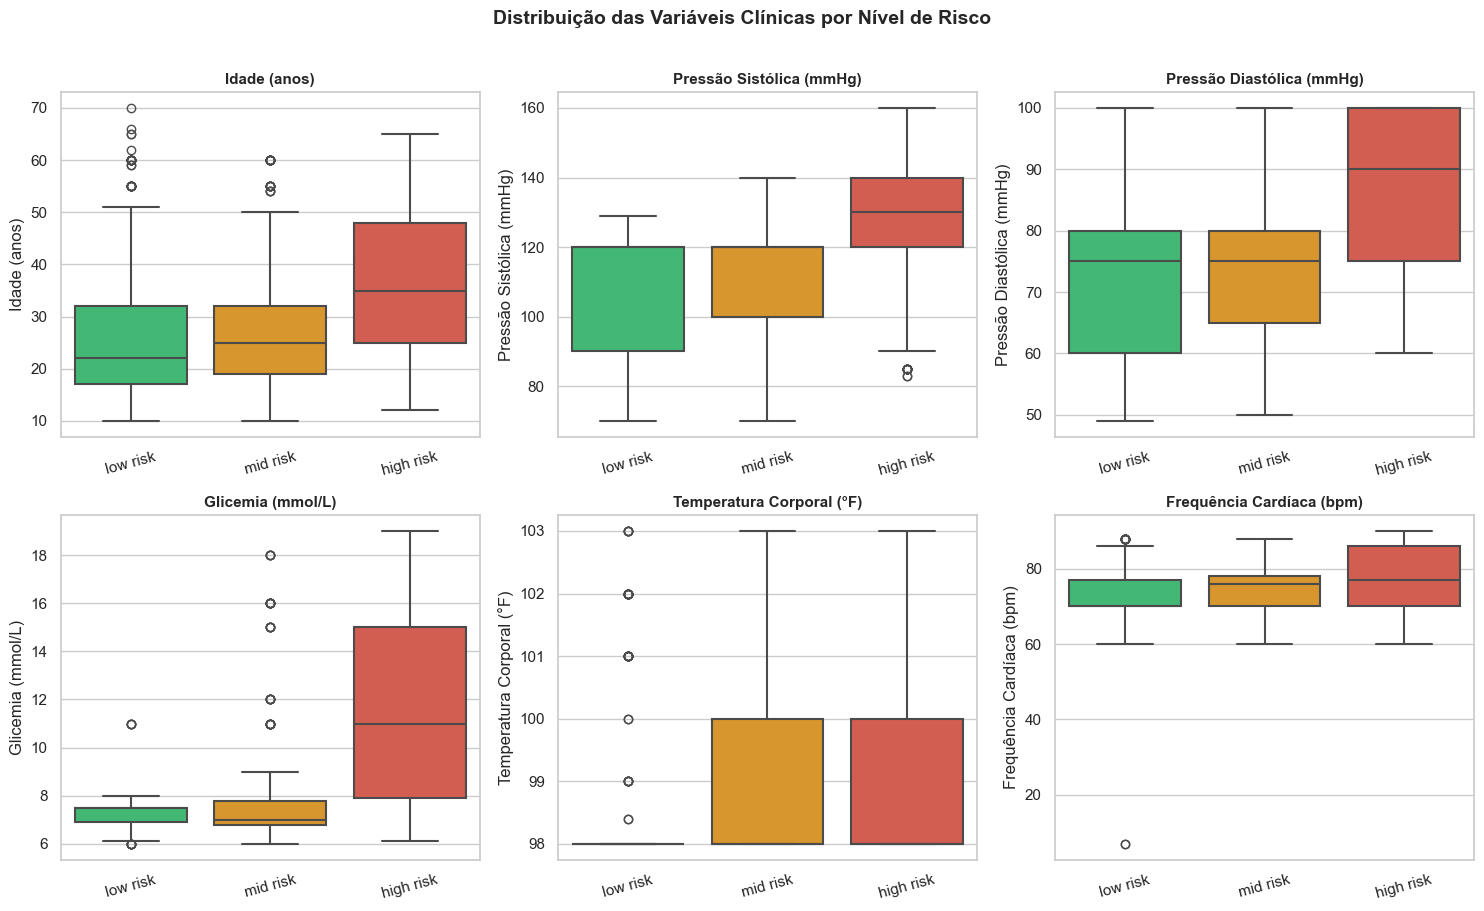

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

feature_labels = {
    'Age'         : 'Idade (anos)',
    'SystolicBP'  : 'Pressão Sistólica (mmHg)',
    'DiastolicBP' : 'Pressão Diastólica (mmHg)',
    'BS'          : 'Glicemia (mmol/L)',
    'BodyTemp'    : 'Temperatura Corporal (°F)',
    'HeartRate'   : 'Frequência Cardíaca (bpm)',
}

palette = {'low risk': '#2ecc71', 'mid risk': '#f39c12', 'high risk': '#e74c3c'}
order = ['low risk', 'mid risk', 'high risk']

for ax, (feat, label) in zip(axes, feature_labels.items()):
    sns.boxplot(
        data=df, x='RiskLevel', y=feat,
        order=order, palette=palette,
        ax=ax, linewidth=1.5
    )
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Distribuição das Variáveis Clínicas por Nível de Risco',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.1 Histogramas com Densidade (KDE)

Os histogramas com curva de densidade (KDE) mostram a forma da distribuição de cada variável  
separada por nível de risco. Sobreposições menores indicam maior poder discriminante da variável.

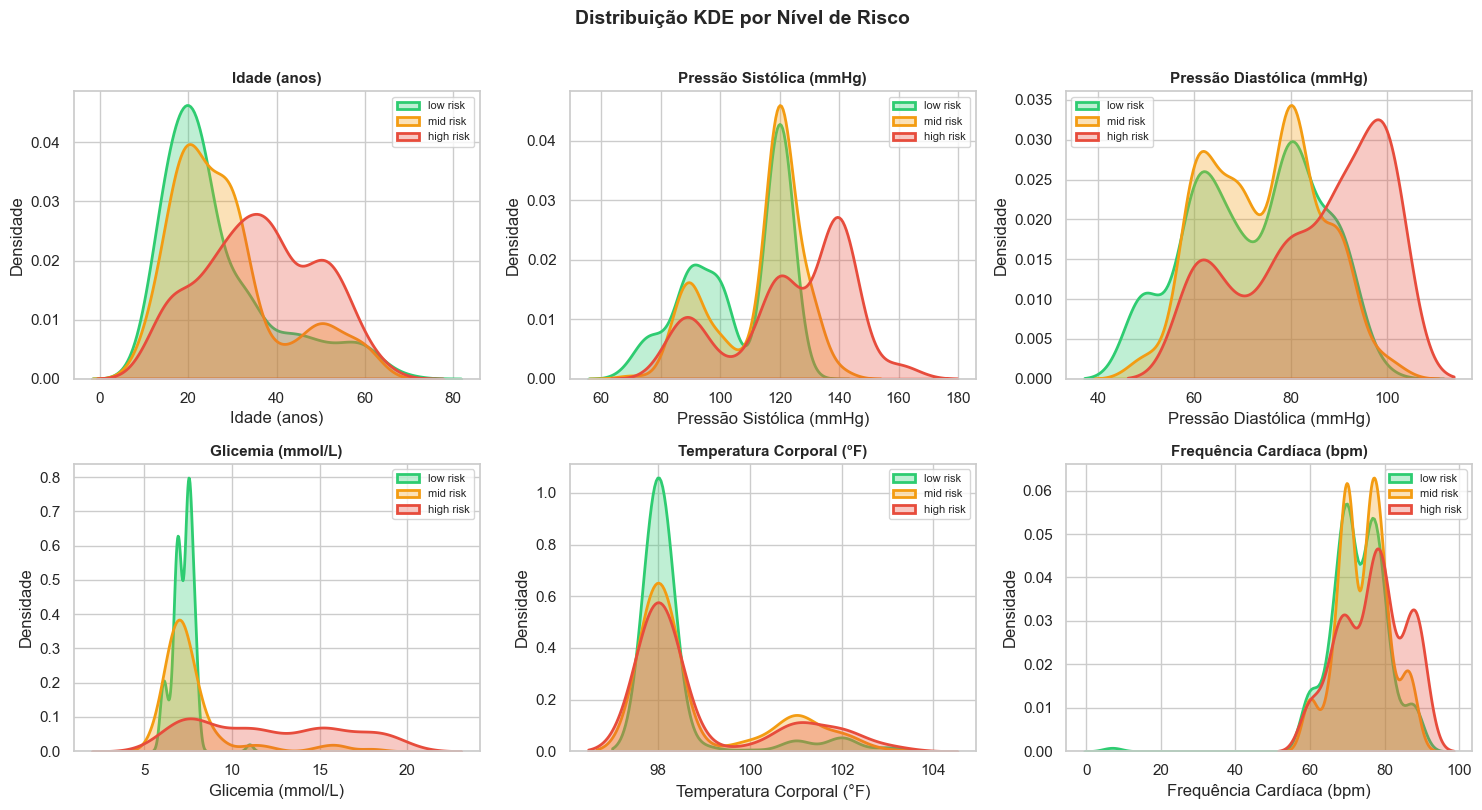

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (feat, label) in zip(axes, feature_labels.items()):
    for risk, color in palette.items():
        subset = df[df['RiskLevel'] == risk][feat]
        sns.kdeplot(subset, ax=ax, color=color, label=risk, fill=True, alpha=0.3, linewidth=2)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=8)

plt.suptitle('Distribuição KDE por Nível de Risco',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Análise de Correlações

O heatmap de correlação revela quais variáveis têm relação linear entre si e com o risco.  
Correlações altas entre features podem indicar **multicolinearidade** — relevante para modelos lineares.

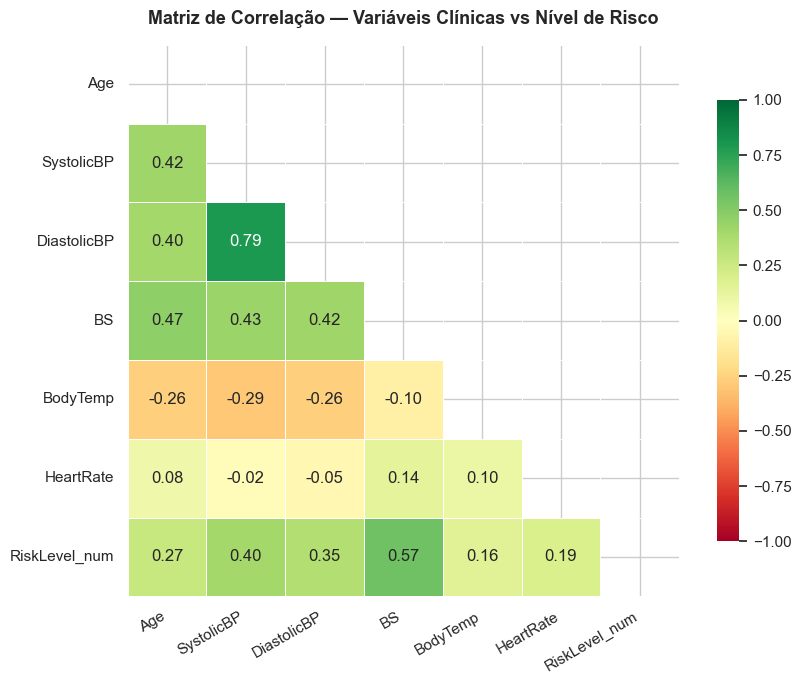

In [10]:
corr_cols = features + ['RiskLevel_num']
corr_matrix = df[corr_cols].corr().round(2)

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title('Matriz de Correlação — Variáveis Clínicas vs Nível de Risco',
          fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 6.1 Variáveis Mais Correlacionadas com o Risco

Ordenamos as correlações com `RiskLevel_num` para identificar os **melhores preditores**  
que alimentarão nosso modelo de detecção precoce de risco materno.

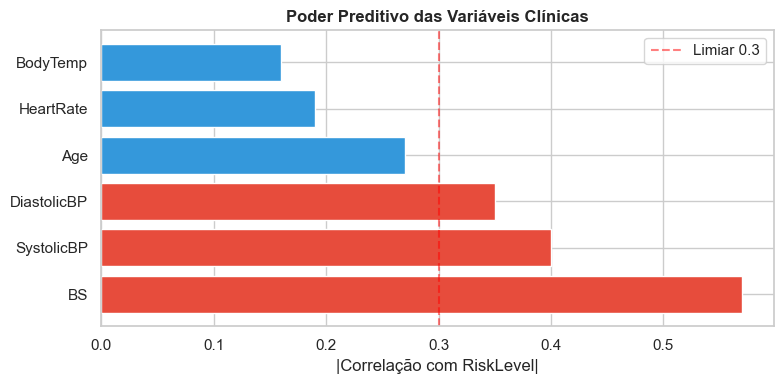

Ranking de correlação com RiskLevel:
  BS              : 0.570
  SystolicBP      : 0.400
  DiastolicBP     : 0.350
  Age             : 0.270
  HeartRate       : 0.190
  BodyTemp        : 0.160


In [11]:
corr_with_risk = corr_matrix['RiskLevel_num'].drop('RiskLevel_num').abs().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
bars = plt.barh(
    corr_with_risk.index,
    corr_with_risk.values,
    color=['#e74c3c' if v > 0.3 else '#3498db' for v in corr_with_risk.values],
    edgecolor='white'
)
plt.axvline(x=0.3, color='red', linestyle='--', alpha=0.5, label='Limiar 0.3')
plt.xlabel('|Correlação com RiskLevel|')
plt.title('Poder Preditivo das Variáveis Clínicas', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print('Ranking de correlação com RiskLevel:')
for feat, val in corr_with_risk.items():
    print(f'  {feat:15s} : {val:.3f}')

## 7. Detecção de Outliers

Usamos o **método IQR** (Intervalo Interquartil) para identificar outliers em cada variável.  
Outliers em dados médicos podem ser erros de medição ou casos clínicos extremos legítimos —  
ambos precisam ser tratados com cuidado antes de treinar o modelo.

In [12]:
def count_outliers_iqr(series: pd.Series) -> dict:
    """Conta outliers pelo método IQR (abaixo de Q1-1.5*IQR ou acima de Q3+1.5*IQR)."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return {
        'count'    : len(outliers),
        'pct'      : round(len(outliers) / len(series) * 100, 2),
        'lower'    : round(lower, 2),
        'upper'    : round(upper, 2),
    }

print(f"{'Variável':<15} {'Outliers':>9} {'%':>7} {'Limite Inf':>12} {'Limite Sup':>12}")
print('-' * 60)

for feat in features:
    info = count_outliers_iqr(df[feat])
    print(f"{feat:<15} {info['count']:>9} {info['pct']:>6.2f}% {info['lower']:>12} {info['upper']:>12}")

Variável         Outliers       %   Limite Inf   Limite Sup
------------------------------------------------------------
Age                     1   0.10%        -11.0         69.0
SystolicBP             10   0.99%         70.0        150.0
DiastolicBP             0   0.00%         27.5        127.5
BS                    210  20.71%         5.25         9.65
BodyTemp              210  20.71%         98.0         98.0
HeartRate               2   0.20%         55.0         95.0


### 7.1 Visualizando Outliers — Scatter Plots das Variáveis Críticas

Plotamos as relações mais importantes para o risco materno:  
**Pressão Arterial Sistólica × Glicemia**, coloridas por nível de risco.

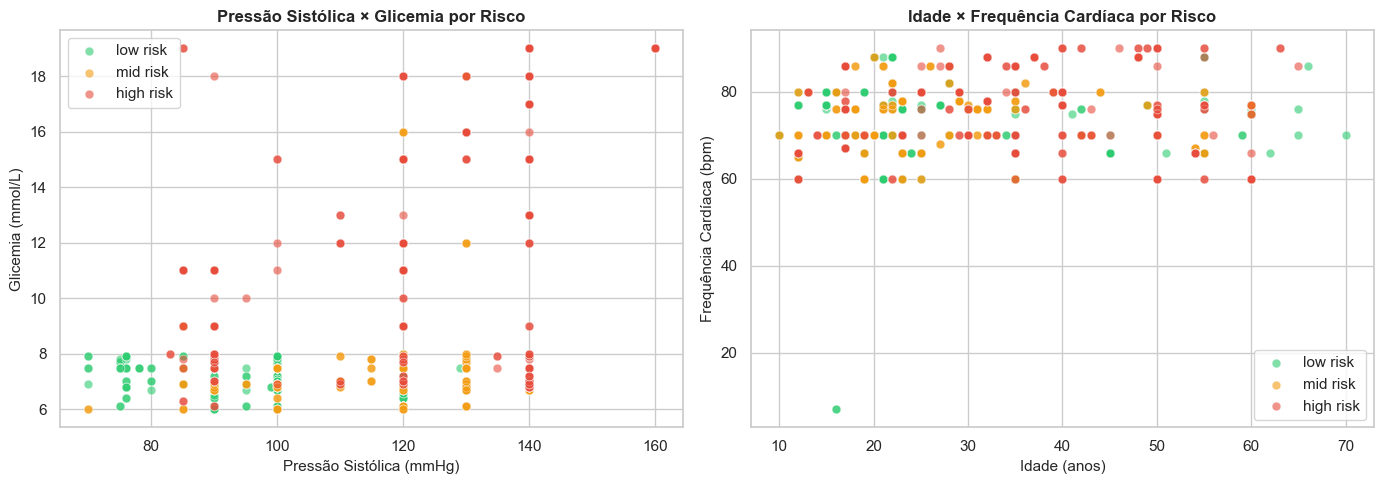

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter 1: Pressão Sistólica vs Glicemia
for risk, color in palette.items():
    sub = df[df['RiskLevel'] == risk]
    axes[0].scatter(sub['SystolicBP'], sub['BS'], c=color, label=risk, alpha=0.6, s=40, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel('Pressão Sistólica (mmHg)', fontsize=11)
axes[0].set_ylabel('Glicemia (mmol/L)', fontsize=11)
axes[0].set_title('Pressão Sistólica × Glicemia por Risco', fontsize=12, fontweight='bold')
axes[0].legend()

# Scatter 2: Idade vs Frequência Cardíaca
for risk, color in palette.items():
    sub = df[df['RiskLevel'] == risk]
    axes[1].scatter(sub['Age'], sub['HeartRate'], c=color, label=risk, alpha=0.6, s=40, edgecolors='white', linewidth=0.5)
axes[1].set_xlabel('Idade (anos)', fontsize=11)
axes[1].set_ylabel('Frequência Cardíaca (bpm)', fontsize=11)
axes[1].set_title('Idade × Frequência Cardíaca por Risco', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Análise de Risco por Faixa Etária

A idade é um fator de risco crítico em saúde materna.  
Segmentamos a população em faixas etárias para entender em que grupos o risco se concentra.

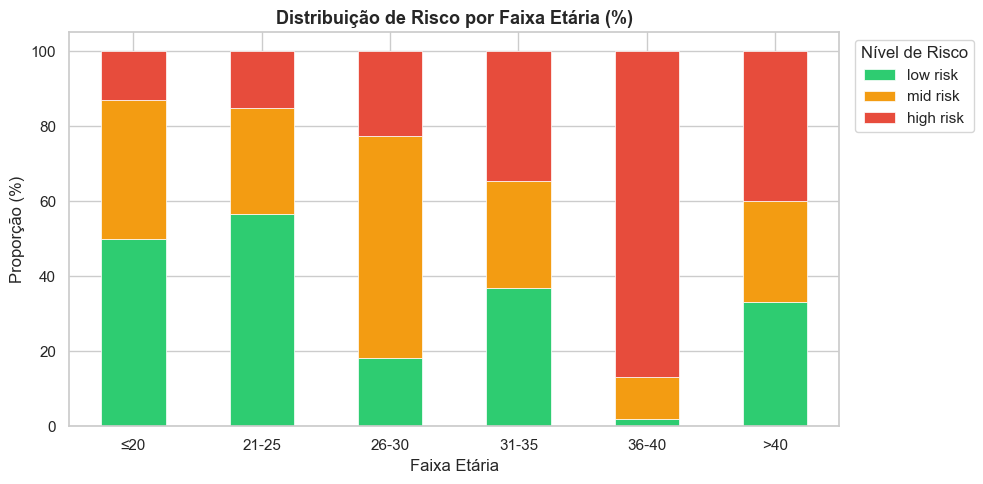


Contagem absoluta por faixa etária e nível de risco:
RiskLevel    low risk  mid risk  high risk
FaixaEtaria                               
≤20               148       110         39
21-25             116        58         31
26-30              20        65         25
31-35              48        37         45
36-40               1         6         46
>40                71        58         86


In [14]:
bins   = [10, 20, 25, 30, 35, 40, 100]
labels = ['≤20', '21-25', '26-30', '31-35', '36-40', '>40']
df['FaixaEtaria'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

age_risk = df.groupby(['FaixaEtaria', 'RiskLevel'], observed=False).size().unstack(fill_value=0)
age_risk = age_risk.reindex(columns=['low risk', 'mid risk', 'high risk'])

# Normalizar para porcentagem
age_risk_pct = age_risk.div(age_risk.sum(axis=1), axis=0) * 100

ax = age_risk_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5),
    color=['#2ecc71', '#f39c12', '#e74c3c'],
    edgecolor='white',
    linewidth=0.5
)
plt.title('Distribuição de Risco por Faixa Etária (%)', fontsize=13, fontweight='bold')
plt.xlabel('Faixa Etária')
plt.ylabel('Proporção (%)')
plt.xticks(rotation=0)
plt.legend(title='Nível de Risco', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

print('\nContagem absoluta por faixa etária e nível de risco:')
print(age_risk)

## 9. Indicadores Clínicos de Alto Risco

Com base em limiares clínicos estabelecidos pela medicina, identificamos quantas pacientes  
apresentam valores preocupantes em cada variável vital:

| Indicador | Limiar de Risco |
|---|---|
| Pressão Sistólica | ≥ 140 mmHg (hipertensão gestacional) |
| Glicemia | ≥ 7.8 mmol/L (diabetes gestacional) |
| Temperatura | ≥ 100°F (febre) |
| Frequência Cardíaca | > 100 bpm (taquicardia) |

In [15]:
clinical_flags = {
    'Hipertensão Sistólica (≥140 mmHg)': df['SystolicBP'] >= 140,
    'Diabetes Gestacional (BS ≥ 7.8)'  : df['BS'] >= 7.8,
    'Febre (Temp ≥ 100°F)'             : df['BodyTemp'] >= 100,
    'Taquicardia (FC > 100 bpm)'       : df['HeartRate'] > 100,
}

print(f"{'Indicador':<40} {'N':>6} {'%':>7} {'% em high risk':>15}")
print('-' * 72)

for label, mask in clinical_flags.items():
    total_flag   = mask.sum()
    pct_total    = total_flag / len(df) * 100
    pct_high     = df.loc[mask, 'RiskLevel'].value_counts(normalize=True).get('high risk', 0) * 100
    print(f'{label:<40} {total_flag:>6} {pct_total:>6.1f}% {pct_high:>14.1f}%')

Indicador                                     N       %  % em high risk
------------------------------------------------------------------------
Hipertensão Sistólica (≥140 mmHg)           130   12.8%           96.2%
Diabetes Gestacional (BS ≥ 7.8)             368   36.3%           58.4%
Febre (Temp ≥ 100°F)                        197   19.4%           35.5%
Taquicardia (FC > 100 bpm)                    0    0.0%            0.0%


## 10. Pré-processamento para o Modelo

Preparamos o dataset para a fase de modelagem:  
normalização das features, split treino/teste e verificação final da distribuição das classes.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[features].values
y = df['RiskLevel_num'].values

# Split estratificado para preservar proporção das classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalização
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Treino  : {X_train.shape[0]} amostras')
print(f'Teste   : {X_test.shape[0]} amostras')
print(f'Features: {X_train.shape[1]}')
print(f'\nDistribuição no treino: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Distribuição no teste : {dict(zip(*np.unique(y_test, return_counts=True)))}')

Treino  : 811 amostras
Teste   : 203 amostras
Features: 6

Distribuição no treino: {np.int64(0): np.int64(325), np.int64(1): np.int64(269), np.int64(2): np.int64(217)}
Distribuição no teste : {np.int64(0): np.int64(81), np.int64(1): np.int64(67), np.int64(2): np.int64(55)}


### 10.1 Teste Rápido com Random Forest

Para validar a qualidade do dataset, treinamos um classificador Random Forest simples.  
Um bom desempenho aqui confirma que as features clínicas têm poder discriminante real.

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_sc, y_train)
y_pred = rf.predict(X_test_sc)

target_names = ['low risk', 'mid risk', 'high risk']
print('=== Relatório de Classificação ===')
print(classification_report(y_test, y_pred, target_names=target_names))

=== Relatório de Classificação ===
              precision    recall  f1-score   support

    low risk       0.87      0.83      0.85        81
    mid risk       0.81      0.81      0.81        67
   high risk       0.90      0.96      0.93        55

    accuracy                           0.86       203
   macro avg       0.86      0.87      0.86       203
weighted avg       0.86      0.86      0.86       203



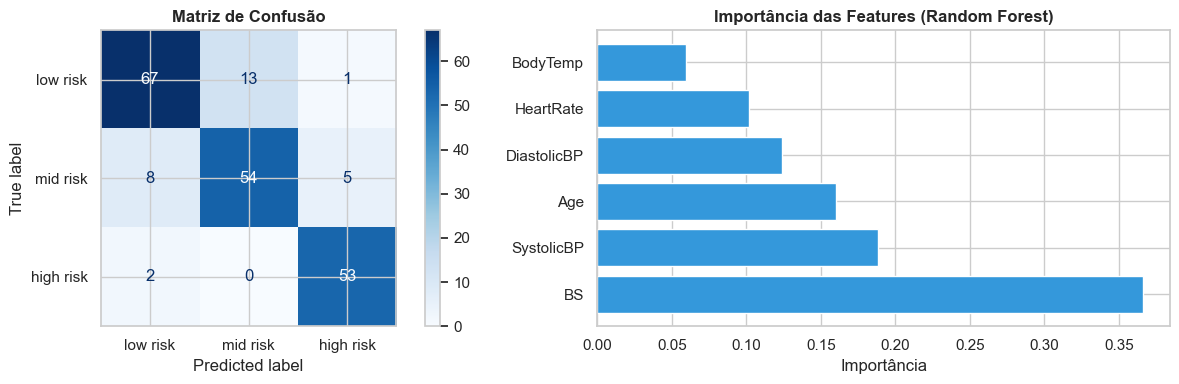

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Matriz de confusão
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=target_names,
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusão', fontweight='bold')

# Importância das features
importances = rf.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]
axes[1].barh(
    [features[i] for i in sorted_idx],
    importances[sorted_idx],
    color='#3498db', edgecolor='white'
)
axes[1].set_title('Importância das Features (Random Forest)', fontweight='bold')
axes[1].set_xlabel('Importância')

plt.tight_layout()
plt.show()

## 11. Conclusões e Próximos Passos

### O que aprendemos com esta EDA:

| Achado | Implicação para o Projeto |
|---|---|
| **Pressão Sistólica** é o melhor preditor de risco | Priorizar monitoramento de BP no pipeline de alertas |
| **Glicemia** diferencia bem alto risco | Incluir BS nas regras do `report_generator.py` |
| Pacientes **>35 anos** têm maior proporção de alto risco | Aplicar threshold mais sensível nessa faixa |
| Dataset sem valores nulos | Pode ir direto para modelagem sem imputação |
| Random Forest atinge boa acurácia | Baseline sólido; próximo passo: XGBoost / LightGBM |

### Próximos passos:
1. **Notebook 02** — EDA do dataset de emoção vocal (RAVDESS + CREMA-D)
2. **Notebook 03** — Fine-tuning do YOLOv8 com m2caiSeg
3. **Notebook 04** — Teste completo do pipeline multimodal
4. Integrar os limiares clínicos identificados aqui ao `src/text/report_generator.py`

In [19]:
import json
from pathlib import Path

# Salvar limiares clínicos para uso no pipeline
clinical_thresholds = {
    'SystolicBP_high_risk' : 140,
    'DiastolicBP_high_risk': 90,
    'BS_high_risk'         : 7.8,
    'BodyTemp_fever'       : 100.0,
    'HeartRate_tachycardia': 100,
    'top_features'         : [features[i] for i in sorted_idx[:3]],
    'feature_importances'  : dict(zip(features, importances.round(4).tolist())),
}

out_path = Path('../data/datasets/maternal_risk/clinical_thresholds.json')
out_path.write_text(json.dumps(clinical_thresholds, indent=2))

print('Limiares clínicos salvos em:', out_path)
print(json.dumps(clinical_thresholds, indent=2))

Limiares clínicos salvos em: ..\data\datasets\maternal_risk\clinical_thresholds.json
{
  "SystolicBP_high_risk": 140,
  "DiastolicBP_high_risk": 90,
  "BS_high_risk": 7.8,
  "BodyTemp_fever": 100.0,
  "HeartRate_tachycardia": 100,
  "top_features": [
    "BS",
    "SystolicBP",
    "Age"
  ],
  "feature_importances": {
    "Age": 0.1599,
    "SystolicBP": 0.1886,
    "DiastolicBP": 0.1242,
    "BS": 0.3659,
    "BodyTemp": 0.0595,
    "HeartRate": 0.1019
  }
}
